<a href="https://colab.research.google.com/github/sugunasri09/24EU01064_Machine-Learning/blob/main/Used_Car_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==============================
# USED CAR PRICE PREDICTION
# Library Imports
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving Car details v3.csv to Car details v3.csv


In [3]:
df = pd.read_csv("Car details v3.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (8128, 13)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Number of rows: 8128
Number of columns: 13

Column Names:
['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque', 'seats']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtype

In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,8128,2058,Maruti Swift Dzire VDI,129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,8128.0,NaN,NaN,NaN,2013.804011,4.044249,1983.0,2011.0,2015.0,2017.0,2020.0
selling_price,8128.0,NaN,NaN,NaN,638271.807702,806253.403508,29999.0,254999.0,450000.0,675000.0,10000000.0
km_driven,8128.0,NaN,NaN,NaN,69819.510827,56550.554958,1.0,35000.0,60000.0,98000.0,2360457.0
fuel,8128,4,Diesel,4402,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_type,8128,3,Individual,6766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,8128,2,Manual,7078,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owner,8128,5,First Owner,5289,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,7907,393,18.9 kmpl,225,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine,7907,121,1248 CC,1017,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df)) * 100
})

missing = missing.sort_values('Missing Values', ascending=False)

missing

,Missing Values,Percentage
torque,222,2.731299
seats,221,2.718996
engine,221,2.718996
mileage,221,2.718996
max_power,215,2.645177
fuel,0,0.000000
km_driven,0,0.000000
selling_price,0,0.000000
year,0,0.000000
name,0,0.000000


In [7]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)
print("Percentage of duplicates:",
      round((duplicate_count / len(df)) * 100, 2), "%")

Number of duplicate rows: 1202
Percentage of duplicates: 14.79 %


In [8]:
print("Target variable: selling_price")

print("\nTarget Statistics:")
print(df['selling_price'].describe())

print("\nTarget Skewness:",
      round(df['selling_price'].skew(), 3))

Target variable: selling_price

Target Statistics:
count    8.128000e+03
mean     6.382718e+05
std      8.062534e+05
min      2.999900e+04
25%      2.549990e+05
50%      4.500000e+05
75%      6.750000e+05
max      1.000000e+07
Name: selling_price, dtype: float64

Target Skewness: 4.194


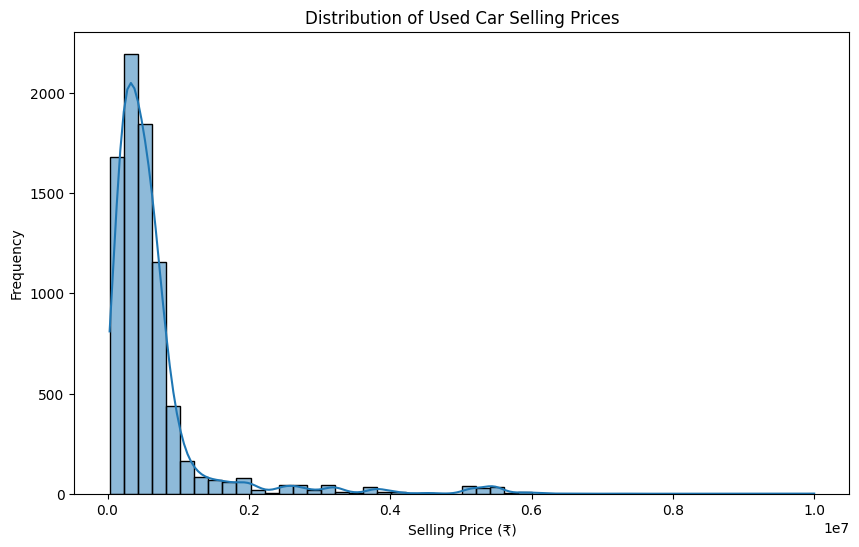

In [9]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df['selling_price'],
    bins=50,
    kde=True
)

plt.title('Distribution of Used Car Selling Prices')
plt.xlabel('Selling Price (₹)')
plt.ylabel('Frequency')

plt.show()

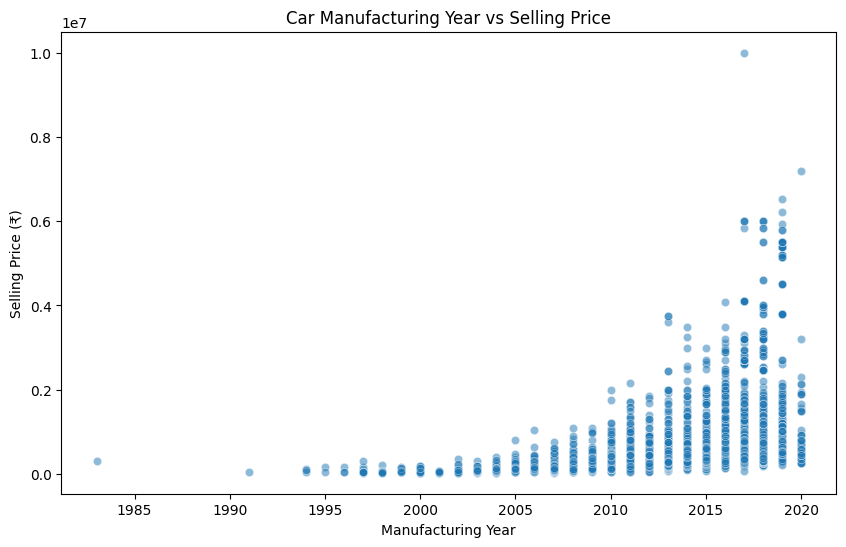

In [10]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='year',
    y='selling_price',
    alpha=0.5
)

plt.title('Car Manufacturing Year vs Selling Price')
plt.xlabel('Manufacturing Year')
plt.ylabel('Selling Price (₹)')

plt.show()

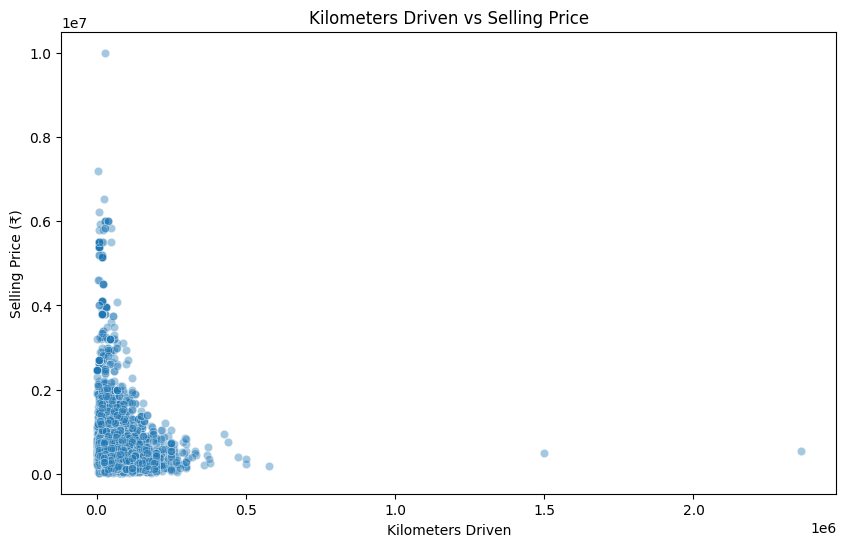

In [11]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='km_driven',
    y='selling_price',
    alpha=0.4
)

plt.title('Kilometers Driven vs Selling Price')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price (₹)')

plt.show()

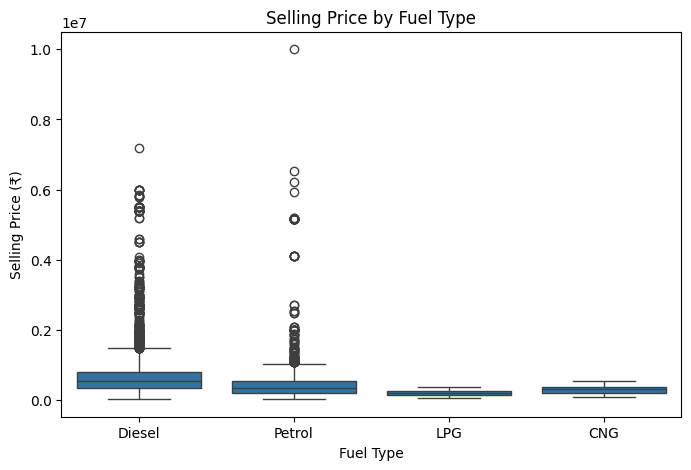

In [12]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='fuel',
    y='selling_price'
)

plt.title('Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price (₹)')

plt.show()

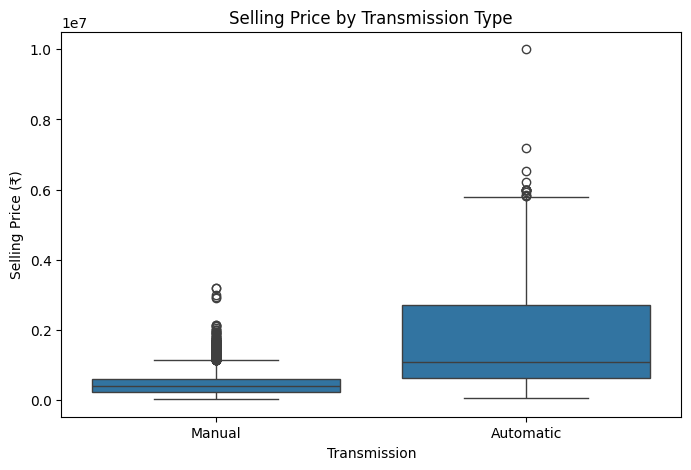

In [13]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='transmission',
    y='selling_price'
)

plt.title('Selling Price by Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Selling Price (₹)')

plt.show()

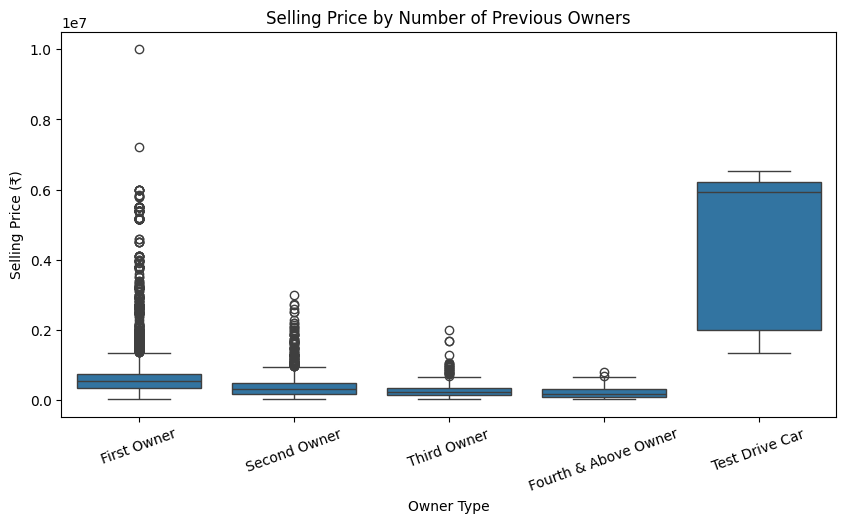

In [14]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x='owner',
    y='selling_price'
)

plt.xticks(rotation=20)

plt.title('Selling Price by Number of Previous Owners')
plt.xlabel('Owner Type')
plt.ylabel('Selling Price (₹)')

plt.show()

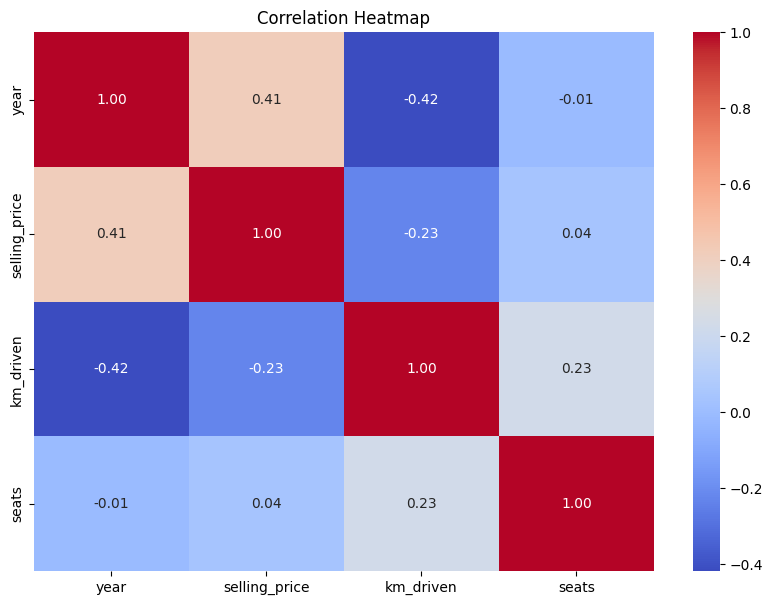

In [15]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

In [16]:
# Assume the latest year available in the dataset represents the reference year
reference_year = df['year'].max()

df['car_age'] = reference_year - df['year']

df[['year', 'car_age']].head()

,year,car_age
0,2014,6
1,2014,6
2,2006,14
3,2010,10
4,2007,13


In [17]:
# Extract numerical values from vehicle specification columns

df['mileage_value'] = (
    df['mileage']
    .str.extract(r'(\d+\.?\d*)')[0]
    .astype(float)
)

df['engine_value'] = (
    df['engine']
    .str.extract(r'(\d+\.?\d*)')[0]
    .astype(float)
)

df['max_power_value'] = (
    df['max_power']
    .str.extract(r'(\d+\.?\d*)')[0]
    .astype(float)
)

df['torque_value'] = (
    df['torque']
    .str.extract(r'(\d+\.?\d*)')[0]
    .astype(float)
)

df[['mileage_value',
    'engine_value',
    'max_power_value',
    'torque_value']].head()

,mileage_value,engine_value,max_power_value,torque_value
0,23.40,1248.0,74.00,190.0
1,21.14,1498.0,103.52,250.0
2,17.70,1497.0,78.00,12.7
3,23.00,1396.0,90.00,22.4
4,16.10,1298.0,88.20,11.5


In [18]:
df['brand'] = df['name'].str.split().str[0]

print("Number of unique brands:",
      df['brand'].nunique())

print("\nTop 20 brands:")
print(df['brand'].value_counts().head(20))

Number of unique brands: 32

Top 20 brands:
brand
Maruti           2448
Hyundai          1415
Mahindra          772
Tata              734
Toyota            488
Honda             467
Ford              397
Chevrolet         230
Renault           228
Volkswagen        186
BMW               120
Skoda             105
Nissan             81
Jaguar             71
Volvo              67
Datsun             65
Mercedes-Benz      54
Fiat               47
Audi               40
Lexus              34
Name: count, dtype: int64


In [19]:
model_df = df[
    [
        'year',
        'car_age',
        'km_driven',
        'fuel',
        'seller_type',
        'transmission',
        'owner',
        'mileage_value',
        'engine_value',
        'max_power_value',
        'torque_value',
        'seats',
        'brand',
        'selling_price'
    ]
].copy()

model_df.head()

,year,car_age,km_driven,fuel,seller_type,transmission,owner,mileage_value,engine_value,max_power_value,torque_value,seats,brand,selling_price
0,2014,6,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,190.0,5.0,Maruti,450000
1,2014,6,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,250.0,5.0,Skoda,370000
2,2006,14,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,12.7,5.0,Honda,158000
3,2010,10,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,22.4,5.0,Hyundai,225000
4,2007,13,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,11.5,5.0,Maruti,130000


In [20]:
print("Before removing duplicates:", model_df.shape)

model_df = model_df.drop_duplicates()

print("After removing duplicates:", model_df.shape)
print("Duplicates remaining:", model_df.duplicated().sum())

Before removing duplicates: (8128, 14)
After removing duplicates: (6907, 14)
Duplicates remaining: 0


In [21]:
X = model_df.drop('selling_price', axis=1)
y = model_df['selling_price']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (6907, 13)
Target shape: (6907,)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5525
Testing samples: 1382


In [23]:
categorical_features = [
    'fuel',
    'seller_type',
    'transmission',
    'owner',
    'brand'
]

numerical_features = [
    'year',
    'car_age',
    'km_driven',
    'mileage_value',
    'engine_value',
    'max_power_value',
    'torque_value',
    'seats'
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['fuel', 'seller_type', 'transmission', 'owner', 'brand']

Numerical features:
['year', 'car_age', 'km_driven', 'mileage_value', 'engine_value', 'max_power_value', 'torque_value', 'seats']


In [24]:
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [25]:
linear_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

linear_pipeline.fit(X_train, y_train)

linear_pred = linear_pipeline.predict(X_test)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


In [26]:
def evaluate_model(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    return {
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2
    }

In [27]:
results = []

results.append(
    evaluate_model(
        'Linear Regression',
        y_test,
        linear_pred
    )
)

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,131747.765618,250658.127201,0.716024


## 1. Baseline Random Forest Model

In [36]:
# ==========================================
# PART 1 - BASELINE RANDOM FOREST
# ==========================================

rf_pipeline_part1 = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_pipeline_part1.fit(X_train, y_train)

part1_predictions = rf_pipeline_part1.predict(X_test)

part1_results = evaluate_model(
    'Random Forest - Part 1',
    y_test,
    part1_predictions
)

print("Part 1 - Baseline Random Forest")
print("--------------------------------")
print(f"MAE  : ₹{part1_results['MAE']:,.2f}")
print(f"RMSE : ₹{part1_results['RMSE']:,.2f}")
print(f"R²   : {part1_results['R2 Score']:.4f}")

Part 1 - Baseline Random Forest
--------------------------------
MAE  : ₹71,348.29
RMSE : ₹125,220.17
R²   : 0.9291


### 2. Model Persistence

In [37]:
# Save the trained Part 1 model

joblib.dump(
    rf_pipeline_part1,
    'used_car_price_model_part1.joblib'
)

print("Part 1 model saved successfully!")

Part 1 model saved successfully!


In [38]:
# Reload the saved model

loaded_part1_model = joblib.load(
    'used_car_price_model_part1.joblib'
)

print("Part 1 model loaded successfully!")

Part 1 model loaded successfully!


In [39]:
# Verify that the reloaded model works without retraining

reloaded_predictions = loaded_part1_model.predict(X_test)

reloaded_mae = mean_absolute_error(
    y_test,
    reloaded_predictions
)

reloaded_rmse = np.sqrt(
    mean_squared_error(y_test, reloaded_predictions)
)

reloaded_r2 = r2_score(
    y_test,
    reloaded_predictions
)

print("Reloaded Model Performance")
print("---------------------------")
print(f"MAE  : ₹{reloaded_mae:,.2f}")
print(f"RMSE : ₹{reloaded_rmse:,.2f}")
print(f"R²   : {reloaded_r2:.4f}")

Reloaded Model Performance
---------------------------
MAE  : ₹71,348.29
RMSE : ₹125,220.17
R²   : 0.9291


In [41]:
# ==========================================
# ERROR ANALYSIS - PUTTING MAE IN CONTEXT
# ==========================================

print("Selling Price Statistics")
print("========================")
print(f"Mean Price   : ₹{y_test.mean():,.2f}")
print(f"Median Price : ₹{y_test.median():,.2f}")
print(f"Minimum Price: ₹{y_test.min():,.2f}")
print(f"Maximum Price: ₹{y_test.max():,.2f}")

mae = mean_absolute_error(y_test, part1_predictions)

print("\nError in Context")
print("================")
print(f"MAE : ₹{mae:,.2f}")
print(f"MAE as % of Mean Price   : {(mae / y_test.mean()) * 100:.2f}%")
print(f"MAE as % of Median Price : {(mae / y_test.median()) * 100:.2f}%")

Selling Price Statistics
Mean Price   : ₹506,869.46
Median Price : ₹420,000.00
Minimum Price: ₹35,000.00
Maximum Price: ₹5,830,000.00

Error in Context
MAE : ₹71,348.29
MAE as % of Mean Price   : 14.08%
MAE as % of Median Price : 16.99%


### 4. Prediction on New/Unseen Data

The saved and reloaded Random Forest model is used to predict the selling price of a new vehicle without retraining the model.

In [40]:
# ==========================================
# PART 1 - NEW/UNSEEN CAR PREDICTION
# ==========================================

# Create a new car record
new_car = pd.DataFrame({
    'year': [2020],
    'car_age': [0],
    'km_driven': [30000],
    'fuel': ['Petrol'],
    'seller_type': ['Dealer'],
    'transmission': ['Automatic'],
    'owner': ['First Owner'],
    'mileage_value': [18.5],
    'engine_value': [1197],
    'max_power_value': [82.0],
    'torque_value': [113.0],
    'seats': [5],
    'brand': ['Hyundai']
})

# Predict using the RELOADED model
new_car_prediction = loaded_part1_model.predict(new_car)

print("New / Unseen Car Details")
print("========================")
print(new_car.to_string(index=False))

print("\nPredicted Used Car Price")
print("========================")
print(f"₹{new_car_prediction[0]:,.0f}")

New / Unseen Car Details
 year  car_age  km_driven   fuel seller_type transmission       owner  mileage_value  engine_value  max_power_value  torque_value  seats   brand
 2020        0      30000 Petrol      Dealer    Automatic First Owner           18.5          1197             82.0         113.0      5 Hyundai

Predicted Used Car Price
₹550,490


### 5. Real-World Application

The developed model can be used to estimate the resale value of used cars based on their age, kilometers driven, brand, fuel type, transmission, ownership history and vehicle specifications.

Buyers can use the predicted price to determine whether a listed vehicle is reasonably priced. Sellers can use it as a reference while setting an asking price, while used-car dealers can use the model to support vehicle valuation and inventory decisions.

The model can be integrated into a web or mobile application where users enter vehicle details and receive an estimated resale price.

# Part 1 Conclusion

A Random Forest regression model was developed to predict used-car selling prices. The model achieved an R² score of 0.9291 on the test set, with an MAE of approximately ₹71,348 and RMSE of approximately ₹125,220. The trained model was successfully saved using Joblib, reloaded without retraining, and used to predict the price of a new unseen vehicle.

# PART 2 — IMPROVE THE ML PROJECT

## 1. Training and Comparison of Multiple ML Models

In [28]:
models = {
    'Linear Regression': LinearRegression(),

    'Decision Tree': DecisionTreeRegressor(
        random_state=42
    ),

    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    'Gradient Boosting': GradientBoostingRegressor(
        random_state=42
    )
}

model_results = []
trained_pipelines = {}

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ]
    )

    print(f"Training {name}...")

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    result = evaluate_model(
        name,
        y_test,
        predictions
    )

    model_results.append(result)
    trained_pipelines[name] = pipeline

results_df = pd.DataFrame(model_results)

results_df.sort_values(
    by='R2 Score',
    ascending=False
)

Training Linear Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...


,Model,MAE,RMSE,R2 Score
2,Random Forest,71348.287869,125220.174685,0.929129
3,Gradient Boosting,85197.174415,148816.713160,0.899903
1,Decision Tree,91889.529305,157681.798932,0.887622
0,Linear Regression,131747.765618,250658.127201,0.716024


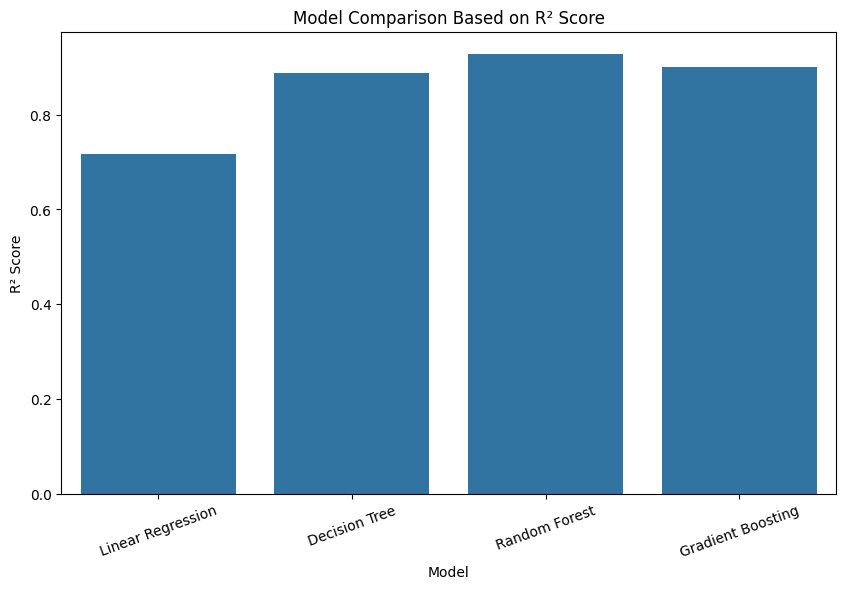

In [29]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x='Model',
    y='R2 Score'
)

plt.title('Model Comparison Based on R² Score')
plt.ylabel('R² Score')
plt.xlabel('Model')

plt.xticks(rotation=20)

plt.show()

In [42]:
# ==========================================
# PART 2 - HYPERPARAMETER TUNING
# ==========================================

from sklearn.model_selection import RandomizedSearchCV

# Random Forest pipeline
rf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Hyperparameter search space
param_distributions = {
    'model__n_estimators': [100, 200, 300, 400],
    'model__max_depth': [None, 10, 15, 20, 25, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', 0.7, 1.0]
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Train and tune the model
random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation RMSE:")
print(f"₹{-random_search.best_score_:,.2f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 30}

Best Cross-Validation RMSE:
₹167,438.31


In [43]:
# ==========================================
# EVALUATE TUNED RANDOM FOREST
# ==========================================

# Get the best tuned model
tuned_rf = random_search.best_estimator_

# Predict on the test set
tuned_predictions = tuned_rf.predict(X_test)

# Calculate evaluation metrics
tuned_mae = mean_absolute_error(y_test, tuned_predictions)
tuned_rmse = mean_squared_error(y_test, tuned_predictions) ** 0.5
tuned_r2 = r2_score(y_test, tuned_predictions)

print("Tuned Random Forest Performance")
print("================================")
print(f"MAE  : ₹{tuned_mae:,.2f}")
print(f"RMSE : ₹{tuned_rmse:,.2f}")
print(f"R²   : {tuned_r2:.4f}")

Tuned Random Forest Performance
MAE  : ₹76,427.12
RMSE : ₹145,112.18
R²   : 0.9048


In [44]:
from sklearn.model_selection import cross_val_score

# Cross-validation performance of baseline Random Forest
baseline_rf_cv = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

print("Baseline Random Forest CV RMSE:")
print(f"₹{-baseline_rf_cv.mean():,.2f}")

print("\nTuned Random Forest CV RMSE:")
print(f"₹{-random_search.best_score_:,.2f}")

Baseline Random Forest CV RMSE:
₹173,205.01

Tuned Random Forest CV RMSE:
₹167,438.31


In [45]:
# ==========================================
# PART 2 - LOG TRANSFORMED RANDOM FOREST
# ==========================================

import numpy as np
from sklearn.compose import TransformedTargetRegressor

# Random Forest pipeline
log_rf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Apply log transformation to target
log_rf_model = TransformedTargetRegressor(
    regressor=log_rf_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

# Train
log_rf_model.fit(X_train, y_train)

# Predict
log_rf_predictions = log_rf_model.predict(X_test)

# Evaluate
log_rf_mae = mean_absolute_error(y_test, log_rf_predictions)
log_rf_rmse = mean_squared_error(y_test, log_rf_predictions) ** 0.5
log_rf_r2 = r2_score(y_test, log_rf_predictions)

print("Log-Transformed Random Forest Performance")
print("==========================================")
print(f"MAE  : ₹{log_rf_mae:,.2f}")
print(f"RMSE : ₹{log_rf_rmse:,.2f}")
print(f"R²   : {log_rf_r2:.4f}")

Log-Transformed Random Forest Performance
MAE  : ₹71,752.85
RMSE : ₹122,921.22
R²   : 0.9317


In [47]:
# ==========================================
# MODEL PERFORMANCE COMPARISON
# ==========================================

# Baseline Random Forest metrics
baseline_mae = mean_absolute_error(y_test, part1_predictions)
baseline_rmse = mean_squared_error(y_test, part1_predictions) ** 0.5
baseline_r2 = r2_score(y_test, part1_predictions)

# Comparison table
comparison_df = pd.DataFrame({
    'Model': [
        'Baseline Random Forest',
        'Tuned Random Forest',
        'Log-Transformed Random Forest'
    ],
    'MAE': [
        baseline_mae,
        tuned_mae,
        log_rf_mae
    ],
    'RMSE': [
        baseline_rmse,
        tuned_rmse,
        log_rf_rmse
    ],
    'R2': [
        baseline_r2,
        tuned_r2,
        log_rf_r2
    ]
})

print(comparison_df.round(4))

                           Model         MAE         RMSE      R2
0         Baseline Random Forest  71348.2879  125220.1747  0.9291
1            Tuned Random Forest  76427.1151  145112.1805  0.9048
2  Log-Transformed Random Forest  71752.8511  122921.2245  0.9317


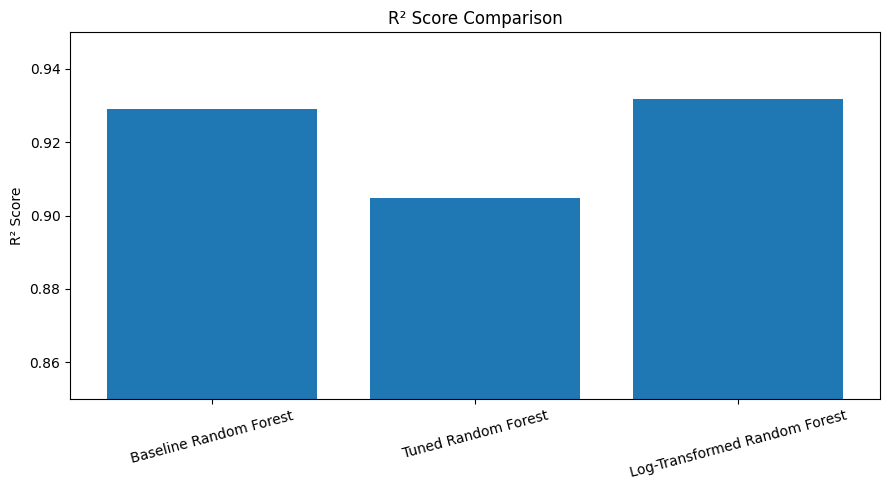

In [48]:
# ==========================================
# PERFORMANCE COMPARISON VISUALIZATION
# ==========================================

import matplotlib.pyplot as plt

# R² Comparison
plt.figure(figsize=(9, 5))
plt.bar(comparison_df['Model'], comparison_df['R2'])
plt.ylabel('R² Score')
plt.title('R² Score Comparison')
plt.xticks(rotation=15)
plt.ylim(0.85, 0.95)
plt.tight_layout()
plt.show()

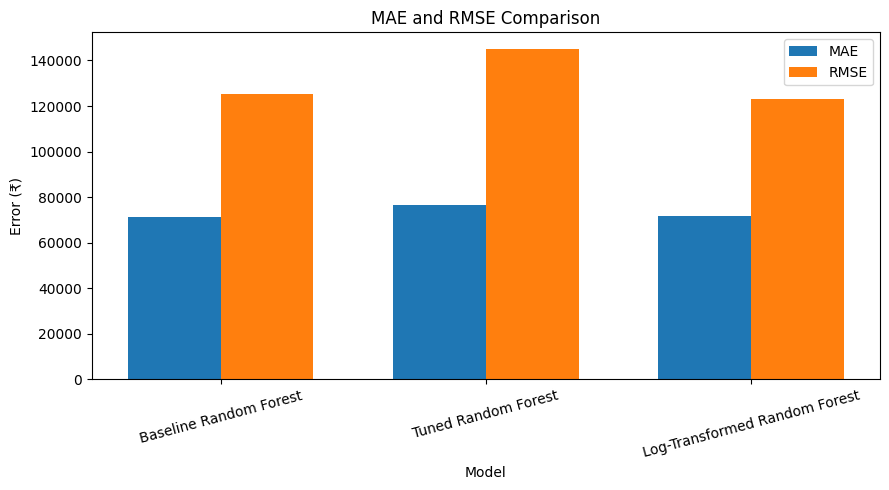

In [49]:
# MAE and RMSE Comparison

plt.figure(figsize=(9, 5))

x = range(len(comparison_df))
width = 0.35

plt.bar(
    [i - width/2 for i in x],
    comparison_df['MAE'],
    width=width,
    label='MAE'
)

plt.bar(
    [i + width/2 for i in x],
    comparison_df['RMSE'],
    width=width,
    label='RMSE'
)

plt.xlabel('Model')
plt.ylabel('Error (₹)')
plt.title('MAE and RMSE Comparison')
plt.xticks(list(x), comparison_df['Model'], rotation=15)
plt.legend()
plt.tight_layout()
plt.show()

In [50]:
# ==========================================
# FEATURE IMPORTANCE
# ==========================================

final_pipeline = log_rf_model.regressor_

feature_names = final_pipeline.named_steps[
    'preprocessor'
].get_feature_names_out()

importances = final_pipeline.named_steps[
    'model'
].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(
    by='Importance',
    ascending=False
)

print("Top 15 Important Features")
print("=========================")
print(feature_importance_df.head(15))

Top 15 Important Features
                    Feature  Importance
0                 num__year    0.377021
5      num__max_power_value    0.289277
1              num__car_age    0.124258
6         num__torque_value    0.053406
4         num__engine_value    0.048163
2            num__km_driven    0.028843
3        num__mileage_value    0.020301
48          cat__brand_Tata    0.012350
7                num__seats    0.008992
17   cat__owner_First Owner    0.003860
49        cat__brand_Toyota    0.003552
26     cat__brand_Chevrolet    0.003349
19  cat__owner_Second Owner    0.002726
40      cat__brand_Mahindra    0.002411
9          cat__fuel_Diesel    0.002166


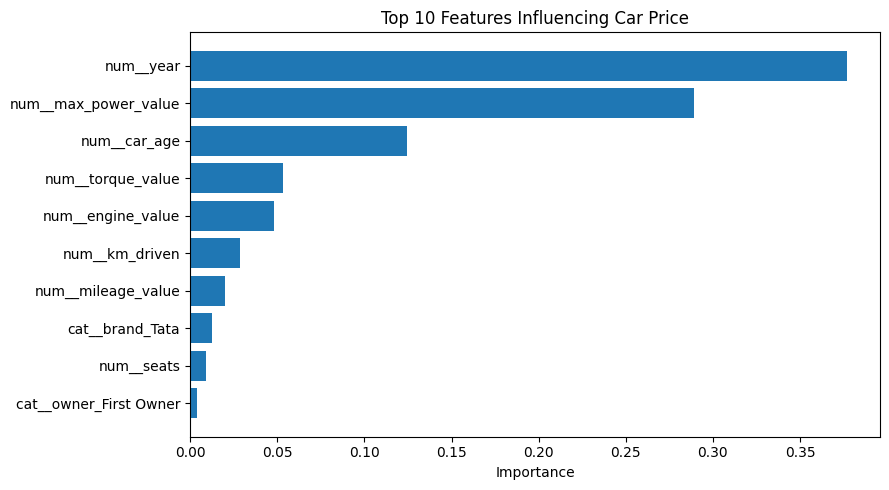

In [51]:
# Top 10 Feature Importance

top_features = feature_importance_df.head(10).sort_values(
    by='Importance'
)

plt.figure(figsize=(9, 5))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Importance')
plt.title('Top 10 Features Influencing Car Price')
plt.tight_layout()
plt.show()

save the final optimised model

In [52]:
# ==========================================
# SAVE FINAL OPTIMIZED MODEL
# ==========================================

import joblib

joblib.dump(log_rf_model, 'final_used_car_price_model.pkl')

print("Final optimized model saved successfully!")

Final optimized model saved successfully!


In [53]:
# ==========================================
# RELOAD FINAL MODEL
# ==========================================

loaded_final_model = joblib.load(
    'final_used_car_price_model.pkl'
)

print("Final optimized model reloaded successfully!")

Final optimized model reloaded successfully!


In [54]:
# ==========================================
# FINAL UNSEEN CAR PREDICTION
# ==========================================

new_car = pd.DataFrame({
    'year': [2020],
    'car_age': [0],
    'km_driven': [30000],
    'fuel': ['Petrol'],
    'seller_type': ['Dealer'],
    'transmission': ['Automatic'],
    'owner': ['First Owner'],
    'mileage_value': [18.5],
    'engine_value': [1197],
    'max_power_value': [82.0],
    'torque_value': [113.0],
    'seats': [5],
    'brand': ['Hyundai']
})

final_prediction = loaded_final_model.predict(new_car)

print("Final Predicted Selling Price")
print("============================")
print(f"₹{final_prediction[0]:,.2f}")

Final Predicted Selling Price
₹554,706.94
